<a href="https://colab.research.google.com/github/syntizen/Prototypical-Neural-Networks-for-3D-Robotic-Welding-Path-Anomaly-Detection/blob/main/Updated_Python_code_for_3D_t_SNE_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
sample joint traj shape (128, 6) sample tip shape (128, 3)
Training tips shape: (2000, 128, 3) labels shape: (2000,) joint traj shape: (2000, 128, 6)
Anomalous test tips shape: (200, 128, 3) anomalous joint traj shape: (200, 128, 6)


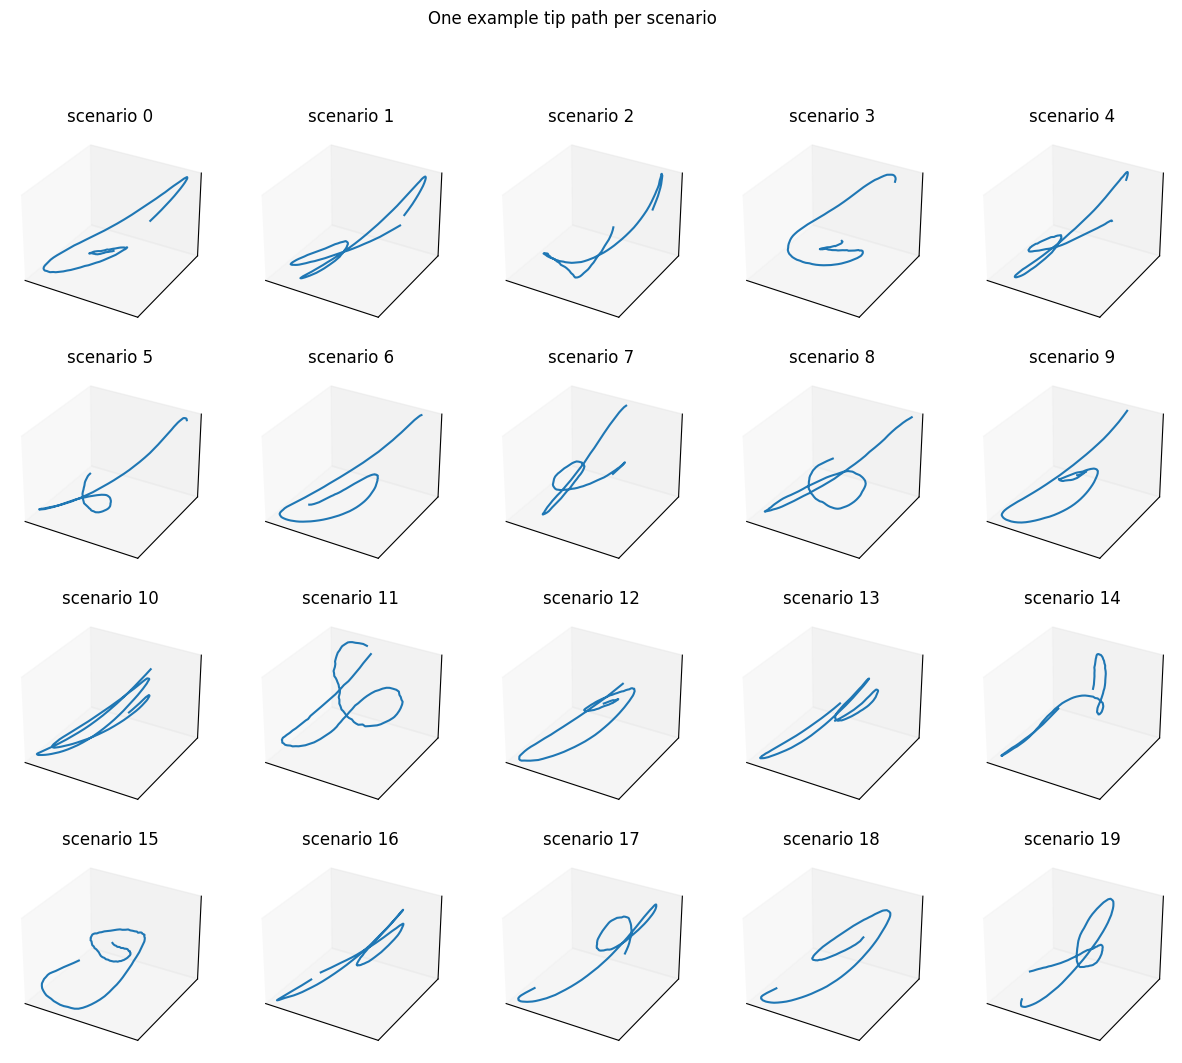

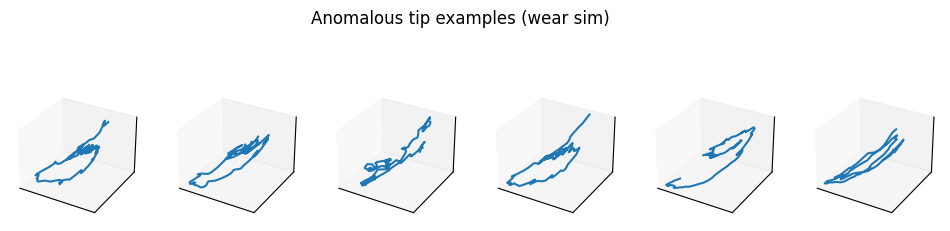

Start episodic training...
Epoch 1/20  loss=0.0308  acc=1.0000
Epoch 2/20  loss=0.0010  acc=1.0000
Epoch 3/20  loss=0.0004  acc=1.0000
Epoch 4/20  loss=0.0002  acc=1.0000
Epoch 5/20  loss=0.0002  acc=1.0000
Epoch 6/20  loss=0.0001  acc=1.0000
Epoch 7/20  loss=0.0001  acc=1.0000
Epoch 8/20  loss=0.0001  acc=1.0000
Epoch 9/20  loss=0.0001  acc=1.0000
Epoch 10/20  loss=0.0000  acc=1.0000
Epoch 11/20  loss=0.0000  acc=1.0000
Epoch 12/20  loss=0.0000  acc=1.0000
Epoch 13/20  loss=0.0000  acc=1.0000
Epoch 14/20  loss=0.0000  acc=1.0000
Epoch 15/20  loss=0.0000  acc=1.0000
Epoch 16/20  loss=0.0000  acc=1.0000
Epoch 17/20  loss=0.0000  acc=1.0000
Epoch 18/20  loss=0.0000  acc=1.0000
Epoch 19/20  loss=0.0000  acc=1.0000
Epoch 20/20  loss=0.0000  acc=1.0000
Training finished.
Built prototypes shape: (20, 128)
Anomaly detection AUC (test21 vs inliers): 0.9837


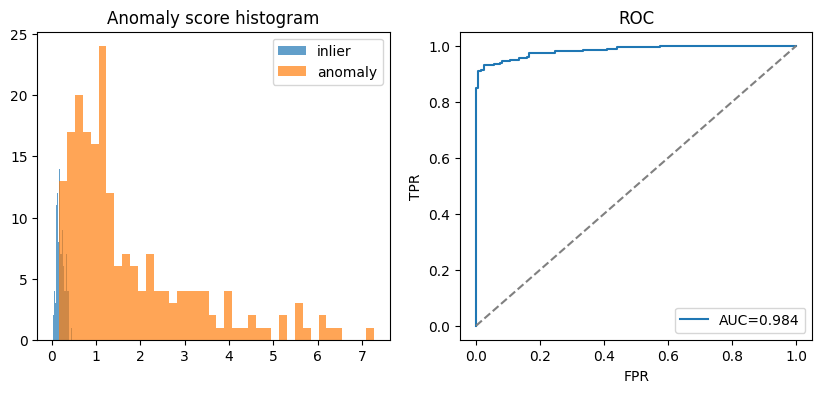

Threshold for TPR>=0.9: 0.4574
Detected fraction among anomalies: 0.910, False positive rate on inliers: 0.005


/tmp/ipykernel_8808/3352024180.py:413: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab20', NUM_SCENARIOS)


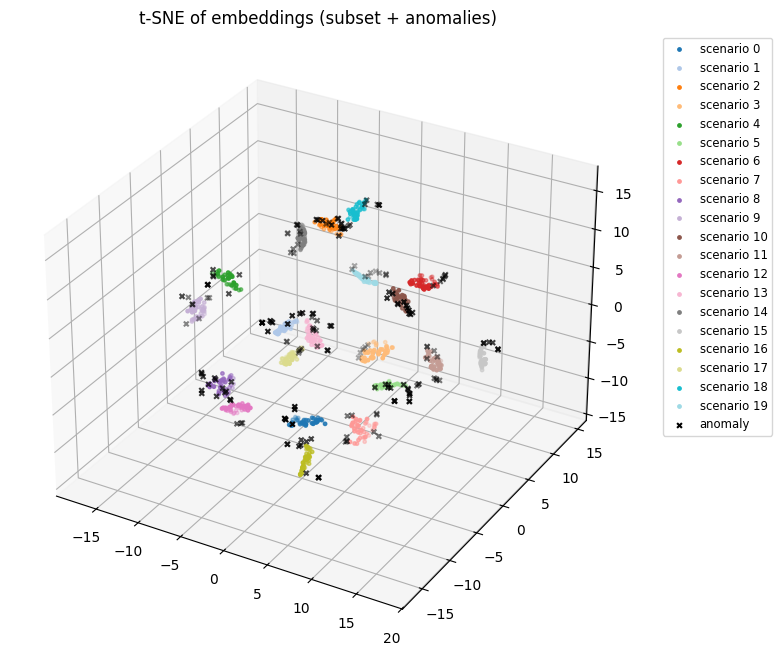

Examples: anomalies (first 6)


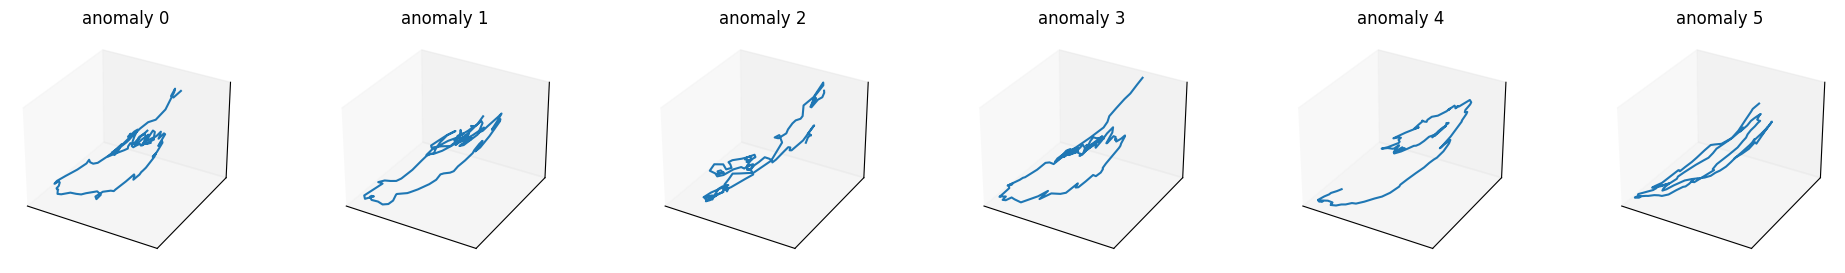

Examples: inliers (heldout) (first 6)


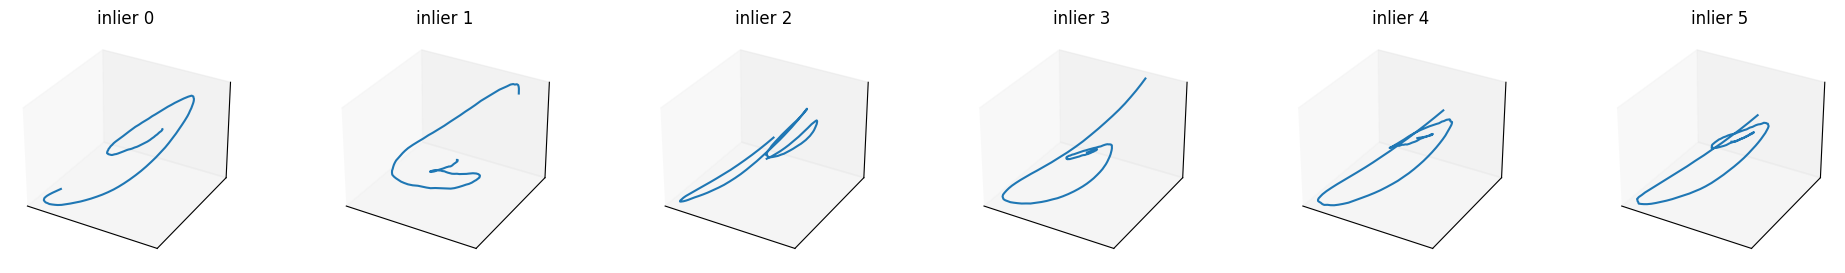

Anomalies nearest-prototype counts (prototype_index:count):
[(np.int64(13), 17), (np.int64(5), 16), (np.int64(8), 15), (np.int64(14), 13), (np.int64(18), 13), (np.int64(10), 12), (np.int64(1), 11), (np.int64(7), 11), (np.int64(11), 11), (np.int64(16), 11)]
Saved data: weld_synth_train.npz, weld_synth_test_anom.npz, weld_prototypes.npy


In [1]:
# Colab-ready: Joint-space -> FK -> generate synthetic welding arm tip paths (20 scenarios),
# train Prototypical Network, test anomaly (wear), and visualize results.

# 0) 安裝、匯入
!pip install -q torch torchvision torchaudio scikit-learn matplotlib tqdm

import os, math, random, time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange, tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

# reproducibility
SEED = 1234
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---------------------------
# 1) Forward kinematics (DH) for a 6-DOF manipulator
# ---------------------------
def dh_transform(a, alpha, d, theta):
    """
    Denavit-Hartenberg transform matrix from parameters.
    a: link length
    alpha: link twist
    d: link offset
    theta: joint angle
    returns 4x4 homogeneous transform
    """
    sa, ca = math.sin(alpha), math.cos(alpha)
    st, ct = math.sin(theta), math.cos(theta)
    T = np.array([
        [ct, -st*ca,  st*sa, a*ct],
        [st,  ct*ca, -ct*sa, a*st],
        [0.0,    sa,     ca,    d],
        [0.0,  0.0,    0.0,  1.0]
    ], dtype=np.float64)
    return T

def fk_dh_all(joint_angles, dh_params):
    """
    joint_angles: array-like (6,) in radians
    dh_params: list of 6 tuples (a, alpha, d, theta_offset)
    we treat the 'theta' in DH as theta_offset + joint_angle
    returns end-effector homogeneous transform (4x4) and position (3,)
    """
    T = np.eye(4)
    for i in range(6):
        a, alpha, d, theta_offset = dh_params[i]
        theta = theta_offset + joint_angles[i]
        T_i = dh_transform(a, alpha, d, theta)
        T = T.dot(T_i)
    pos = T[:3,3].copy()
    return T, pos

# Example (simplified) DH params for a 6-DOF industrial arm (units: meters, radians)
# These are representative values (not for a specific robot), enough to create realistic workspace.
# Each entry: (a_i, alpha_i, d_i, theta_offset_i)
DH_PARAMS = [
    (0.0,      np.pi/2,  0.34,  0.0),   # base -> joint1
    (0.27,      0.0,      0.0,   0.0),   # joint2
    (0.07,      np.pi/2,  0.0,   0.0),   # joint3
    (0.0,      -np.pi/2,  0.30,  0.0),   # joint4
    (0.0,       np.pi/2,  0.0,   0.0),   # joint5
    (0.0,       0.0,      0.06,  0.0),   # joint6 (tool)
]

# helper to compute tip positions for a trajectory of joint angles shape (T,6)
def fk_trajectory(joint_traj, dh_params=DH_PARAMS):
    # joint_traj: (T,6)
    positions = np.zeros((joint_traj.shape[0], 3), dtype=np.float32)
    for i in range(len(joint_traj)):
        _, pos = fk_dh_all(joint_traj[i], dh_params)
        positions[i] = pos.astype(np.float32)
    return positions   # (T,3)

# ---------------------------
# 2) Joint-space trajectory generator (simulate welding tasks)
# ---------------------------
TIMESTEPS = 128

def time_series(T=TIMESTEPS):
    return np.linspace(0, 1, T)

def smooth_noise(T, scale=0.01, smooth_sigma=3):
    # create smoothed noise by gaussian filter in 1D
    raw = np.random.randn(T)
    # simple smoothing via convolution (small kernel)
    kernel_size = max(3, int(smooth_sigma*2+1))
    kern = np.exp(-0.5 * ((np.arange(kernel_size) - kernel_size//2)/(smooth_sigma))**2)
    kern = kern / kern.sum()
    from numpy import convolve
    sm = convolve(raw, kern, mode='same')
    return sm * scale

def generate_joint_traj_for_scenario(scenario_idx, timesteps=TIMESTEPS, variation=True):
    """
    Each scenario defines a nominal joint-space pattern representing a welding pass.
    We'll synthesize joint trajectories by:
      - a base joint offset (6-dim)
      - low-frequency sinusoidal / polynomial components
      - small smooth stochastic variation to emulate AI corrections
    """
    T = timesteps
    t = time_series(T)
    # base joint mean for scenario (spread across workspace)
    base = np.array([
        np.deg2rad(20 + 10*scenario_idx%6),   # j1
        np.deg2rad(-30 + 5*(scenario_idx%5)), # j2
        np.deg2rad(40 - 6*(scenario_idx%4)),  # j3
        np.deg2rad(0 + 8*(scenario_idx%3)),   # j4
        np.deg2rad(10 + 4*(scenario_idx%2)),  # j5
        np.deg2rad(0)                       # j6
    ], dtype=np.float32)
    # add scenario-specific waveform frequencies/amplitudes
    joint_traj = np.zeros((T,6), dtype=np.float32)
    for j in range(6):
        amp = 0.12 + 0.06*((j + scenario_idx) % 4)      # amplitude per joint
        freq = 1 + ((j+scenario_idx) % 3) * 0.5
        phase = (j * 0.4 + scenario_idx*0.2)
        # core sinusoidal/linear motion simulating a sweep along weld
        core = base[j] + amp * np.sin(2*np.pi*freq*t + phase)
        # optional drift slowly across t (simulate slow adjustment)
        drift = (np.sin(np.pi*t * (1 + 0.1*scenario_idx)) * (0.02*(scenario_idx%3)))
        joint_traj[:, j] = core + drift
        # add small smooth AI corrections if variation
        if variation:
            corr = smooth_noise(T, scale=0.01, smooth_sigma=4)
            joint_traj[:, j] += corr
    return joint_traj   # (T,6)

# quick check: generate one scenario and FK to tip
_sample_joint = generate_joint_traj_for_scenario(0)
_sample_tip = fk_trajectory(_sample_joint)
print("sample joint traj shape", _sample_joint.shape, "sample tip shape", _sample_tip.shape)

# ---------------------------
# 3) Create dataset: 20 scenarios x 100 samples each
# ---------------------------
NUM_SCENARIOS = 20
SAMPLES_PER_SCENARIO = 100
TOTAL_TRAIN = NUM_SCENARIOS * SAMPLES_PER_SCENARIO

X = []   # tip positions (T,3)
Y = []   # labels 0..19 scenario id
JX = []  # keep joint trajectories if needed for inspection (T,6)

for s in range(NUM_SCENARIOS):
    for k in range(SAMPLES_PER_SCENARIO):
        # generate base joint traj for scenario, plus small sample-specific perturbations
        jt = generate_joint_traj_for_scenario(s, variation=True)
        # add sample-level smooth perturbation to emulate AI correction or sensor noise
        for j in range(6):
            jt[:,j] += smooth_noise(TIMESTEPS, scale=0.005, smooth_sigma=6)  # small smooth tweak
        tip = fk_trajectory(jt)
        X.append(tip)
        Y.append(s)
        JX.append(jt)
X = np.stack(X).astype(np.float32)  # (2000, T, 3)
Y = np.array(Y, dtype=np.int64)
JX = np.stack(JX).astype(np.float32)  # (2000, T, 6)
print("Training tips shape:", X.shape, "labels shape:", Y.shape, "joint traj shape:", JX.shape)

# ---------------------------
# 4) Generate anomalous test data (scenario 21) simulating wear
#    wear modes: joint drift, increased jitter, occasional stuck segments, reduced accuracy
# ---------------------------
NUM_ANOM = 200
test_X = []
test_JX = []
for i in range(NUM_ANOM):
    # base from a random normal scenario trajectory (so anomalies are near normal tasks)
    base_s = np.random.randint(0, NUM_SCENARIOS)
    jt = generate_joint_traj_for_scenario(base_s, variation=True)
    # apply wear effects:
    # 1) slow additive drift on one joint (simulate encoder offset or backlash)
    worn_joint = np.random.randint(0,6)
    drift_amp = np.random.uniform(0.02, 0.12)  # radians over trajectory
    jt[:, worn_joint] += np.linspace(0, drift_amp, TIMESTEPS)
    # 2) occasional stuck segment (robot temporarily cannot move joint)
    if np.random.rand() < 0.4:
        idx = np.random.randint(10, TIMESTEPS-20)
        duration = np.random.randint(3, 12)
        # freeze joint value for that window (simulate jam)
        jt[idx:idx+duration, :] = jt[idx:idx+1, :].copy()
    # 3) increase high-frequency jitter (simulate mechanical looseness)
    for j in range(6):
        jt[:, j] += smooth_noise(TIMESTEPS, scale=0.02 + 0.03*np.random.rand(), smooth_sigma=1)
    tip = fk_trajectory(jt)
    test_X.append(tip.astype(np.float32))
    test_JX.append(jt.astype(np.float32))
test_X = np.stack(test_X)
test_JX = np.stack(test_JX)
print("Anomalous test tips shape:", test_X.shape, "anomalous joint traj shape:", test_JX.shape)

# ---------------------------
# 5) Visualize some samples (one per scenario) and some anomalies
# ---------------------------
def plot_one_per_scenario(X, Y, num_scenarios=NUM_SCENARIOS):
    cols = 5
    rows = math.ceil(num_scenarios/cols)
    fig = plt.figure(figsize=(cols*3, rows*3))
    for s in range(num_scenarios):
        ax = fig.add_subplot(rows, cols, s+1, projection='3d')
        idx = np.where(Y==s)[0][0]
        traj = X[idx]
        ax.plot(traj[:,0], traj[:,1], traj[:,2])
        ax.set_title(f"scenario {s}")
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    plt.suptitle("One example tip path per scenario")
    plt.show()

plot_one_per_scenario(X, Y)

def plot_anomaly_examples(test_X, n=6):
    fig = plt.figure(figsize=(12,3))
    for i in range(n):
        ax = fig.add_subplot(1, n, i+1, projection='3d')
        tr = test_X[i]
        ax.plot(tr[:,0], tr[:,1], tr[:,2])
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    plt.suptitle("Anomalous tip examples (wear sim)")
    plt.show()

plot_anomaly_examples(test_X, n=6)

# ---------------------------
# 6) Prepare dataset for ProtoNet (we'll use tip trajectories as input: (T,3))
# ---------------------------
class TipDataset(Dataset):
    def __init__(self, X, Y=None):
        self.X = X
        self.Y = Y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        x = self.X[idx].transpose(1,0)  # (3, T)
        if self.Y is None:
            return torch.from_numpy(x).float()
        return torch.from_numpy(x).float(), int(self.Y[idx])

# ---------------------------
# 7) Model: 1D-CNN encoder (same idea as before)
# ---------------------------
class ConvEncoder(nn.Module):
    def __init__(self, in_channels=3, emb_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, emb_dim),
        )
    def forward(self, x):
        return self.net(x)

# episodic sampler for tips
def sample_episode(X_np, Y_np, n_way=5, k_shot=5, q_query=10):
    classes = np.random.choice(np.unique(Y_np), size=n_way, replace=False)
    support_x, support_y, query_x, query_y = [], [], [], []
    for i,c in enumerate(classes):
        idxs = np.where(Y_np==c)[0]
        chosen = np.random.choice(idxs, size=k_shot+q_query, replace=False)
        s = chosen[:k_shot]; q = chosen[k_shot:]
        for si in s:
            support_x.append(X_np[si].transpose(1,0))
            support_y.append(i)
        for qi in q:
            query_x.append(X_np[qi].transpose(1,0))
            query_y.append(i)
    support_x = torch.from_numpy(np.stack(support_x)).float()
    support_y = torch.tensor(support_y, dtype=torch.long)
    query_x = torch.from_numpy(np.stack(query_x)).float()
    query_y = torch.tensor(query_y, dtype=torch.long)
    return support_x, support_y, query_x, query_y

# ---------------------------
# 8) Train Prototypical Network (episodic)
# ---------------------------
encoder = ConvEncoder(in_channels=3, emb_dim=128).to(device)
optimizer = torch.optim.Adam(encoder.parameters(), lr=1e-3)
n_epochs = 20            # 可調整
episodes_per_epoch = 150 # 可調整
n_way = 8
k_shot = 5
q_query = 10

print("Start episodic training...")
for epoch in range(n_epochs):
    encoder.train()
    total_loss = 0.0
    total_acc = 0.0
    for ep in range(episodes_per_epoch):
        s_x, s_y, q_x, q_y = sample_episode(X, Y, n_way=n_way, k_shot=k_shot, q_query=q_query)
        s_x = s_x.to(device); q_x = q_x.to(device)
        s_emb = encoder(s_x)
        q_emb = encoder(q_x)
        prototypes = []
        for i in range(n_way):
            emb_i = s_emb[i*k_shot:(i+1)*k_shot]
            prototypes.append(emb_i.mean(dim=0))
        prototypes = torch.stack(prototypes)  # (n_way, emb)
        dists = torch.cdist(q_emb, prototypes, p=2)
        logits = -dists
        loss = F.cross_entropy(logits, q_y.to(device))
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        total_acc += (preds.cpu()==q_y).float().mean().item()
    avg_loss = total_loss / episodes_per_epoch
    avg_acc = total_acc / episodes_per_epoch
    print(f"Epoch {epoch+1}/{n_epochs}  loss={avg_loss:.4f}  acc={avg_acc:.4f}")
print("Training finished.")

# ---------------------------
# 9) Build prototypes from full training data (20 scenarios)
# ---------------------------
encoder.eval()
batch_size = 128
all_embs = []
with torch.no_grad():
    for i in range(0, len(X), batch_size):
        batch = torch.from_numpy(X[i:i+batch_size].transpose(0,2,1)).float().to(device)
        emb = encoder(batch)  # (B, emb)
        all_embs.append(emb.cpu().numpy())
all_embs = np.vstack(all_embs)  # (2000, emb_dim)

all_prototypes = []
for cls in range(NUM_SCENARIOS):
    idxs = np.where(Y==cls)[0]
    proto = all_embs[idxs].mean(axis=0)
    all_prototypes.append(proto)
all_prototypes = np.stack(all_prototypes)  # (20, emb_dim)
print("Built prototypes shape:", all_prototypes.shape)

# ---------------------------
# 10) Score anomalies (distance to nearest prototype)
# ---------------------------
def compute_scores(samples_np):
    with torch.no_grad():
        batch = torch.from_numpy(samples_np.transpose(0,2,1)).float().to(device)
        emb = encoder(batch).cpu().numpy()
    dists = np.linalg.norm(emb[:, None, :] - all_prototypes[None, :, :], axis=2)  # (M,20)
    min_dist = dists.min(axis=1)
    return min_dist, dists, emb

test_scores, test_dists, test_embs = compute_scores(test_X)
# sample inlier heldout
np.random.seed(42)
inlier_idx = np.random.choice(len(X), size=len(test_X), replace=False)
inlier_X = X[inlier_idx]
inlier_scores, inlier_dists, inlier_embs = compute_scores(inlier_X)

# ---------------------------
# 11) Evaluate & Visualize results
# ---------------------------
y_true = np.concatenate([np.zeros_like(inlier_scores), np.ones_like(test_scores)])  # 0=inlier,1=anomaly
y_scores = np.concatenate([inlier_scores, test_scores])
auc = roc_auc_score(y_true, y_scores)
print("Anomaly detection AUC (test21 vs inliers):", auc)

# histogram + ROC
fpr, tpr, th = roc_curve(y_true, y_scores)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(inlier_scores, bins=40, alpha=0.7, label='inlier')
plt.hist(test_scores, bins=40, alpha=0.7, label='anomaly')
plt.legend(); plt.title("Anomaly score histogram")
plt.subplot(1,2,2)
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],'--', color='gray'); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.title("ROC")
plt.show()

# choose threshold for TPR >= 0.9 (if available)
target_tpr = 0.9
idx = np.argmax(tpr >= target_tpr)
thr = th[idx] if idx < len(th) else th[-1]
detected = (test_scores >= thr).mean()
false_pos = (inlier_scores >= thr).mean()
print(f"Threshold for TPR>={target_tpr}: {thr:.4f}")
print(f"Detected fraction among anomalies: {detected:.3f}, False positive rate on inliers: {false_pos:.3f}")

# t-SNE of embeddings: pick subset for speed
n_per_class = 40
sel_idxs = []
for cls in range(NUM_SCENARIOS):
    ids = np.where(Y==cls)[0]
    pick = np.random.choice(ids, size=min(len(ids), n_per_class), replace=False)
    sel_idxs.extend(pick.tolist())
sel_embs = all_embs[sel_idxs]
sel_labels = Y[sel_idxs]
# append anomaly embeddings
n_anom_tsne = min(200, test_embs.shape[0])
tsne_pool = np.vstack([sel_embs, test_embs[:n_anom_tsne]])
tsne_labels = np.concatenate([sel_labels, np.ones(n_anom_tsne)*999])
tsne = TSNE(n_components=3, random_state=SEED, perplexity=30, init='pca') # MODIFIED: 3 components for 3D
tsne3 = tsne.fit_transform(tsne_pool)
plt.figure(figsize=(10,8))
ax = plt.subplot(111, projection='3d') # MODIFIED: Use 3D projection
palette = plt.cm.get_cmap('tab20', NUM_SCENARIOS)
for c in range(NUM_SCENARIOS):
    mask = tsne_labels == c
    if mask.sum()>0:
        ax.scatter(tsne3[mask,0], tsne3[mask,1], tsne3[mask,2], s=6, color=palette(c), label=f"scenario {c}") # MODIFIED: Plot 3D data
# anomalies
mask_an = tsne_labels == 999
ax.scatter(tsne3[mask_an,0], tsne3[mask_an,1], tsne3[mask_an,2], s=12, color='k', label='anomaly', marker='x') # MODIFIED: Plot 3D data
ax.set_title("t-SNE of embeddings (subset + anomalies)")
ax.legend(bbox_to_anchor=(1.05,1), loc='upper left', fontsize='small')
plt.show()

# plot several example tip trajectories: inlier vs anomaly
def plot_examples_3d(trajs, titles=None, n=6):
    fig = plt.figure(figsize=(4*n,3))
    for i in range(n):
        ax = fig.add_subplot(1, n, i+1, projection='3d')
        ax.plot(trajs[i][:,0], trajs[i][:,1], trajs[i][:,2])
        if titles is not None:
            ax.set_title(titles[i])
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    plt.show()

print("Examples: anomalies (first 6)")
plot_examples_3d(test_X, titles=[f"anomaly {i}" for i in range(6)], n=6)
print("Examples: inliers (heldout) (first 6)")
plot_examples_3d(inlier_X, titles=[f"inlier {i}" for i in range(6)], n=6)

# show distribution of which prototype (class) each anomaly is closest to (for diagnosis)
closest_proto = np.argmin(test_dists, axis=1)
import collections
cnt = collections.Counter(closest_proto)
print("Anomalies nearest-prototype counts (prototype_index:count):")
print(sorted(cnt.items(), key=lambda x:-x[1])[:10])

# save datasets and prototypes
np.savez_compressed("weld_synth_train.npz", X=X, Y=Y, JX=JX)
np.savez_compressed("weld_synth_test_anom.npz", X=test_X, JX=test_JX)
np.save("weld_prototypes.npy", all_prototypes)
print("Saved data: weld_synth_train.npz, weld_synth_test_anom.npz, weld_prototypes.npy")